# Titanic Dataset: Complete Exploratory Data Analysis (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')
%matplotlib inline

# Download the Titanic dataset from a common source (Kaggle) if not already present
!wget -nc https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O /content/titanic.csv

df = pd.read_csv('/content/titanic.csv')

print("Dataset Head")
display(df.head())
print(f"\n Shape: {df.shape}")
print("\n Info")
df.info()
print("\n Summary Statistics (Numerical")
display(df.describe())

File ‘/content/titanic.csv’ already there; not retrieving.
Dataset Head


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



 Shape: (891, 12)

 Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

 Summary Statistics (Numerical


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 2. Missing Values and Duplicates

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Duplicate rows: 0


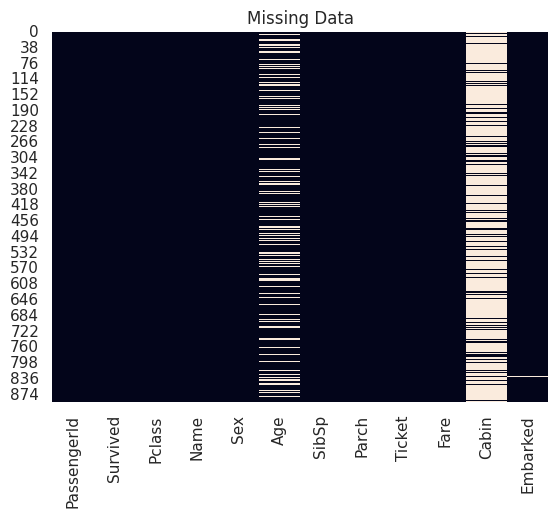

In [2]:
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data")
plt.show()

### 3. Numerical Data Distribution

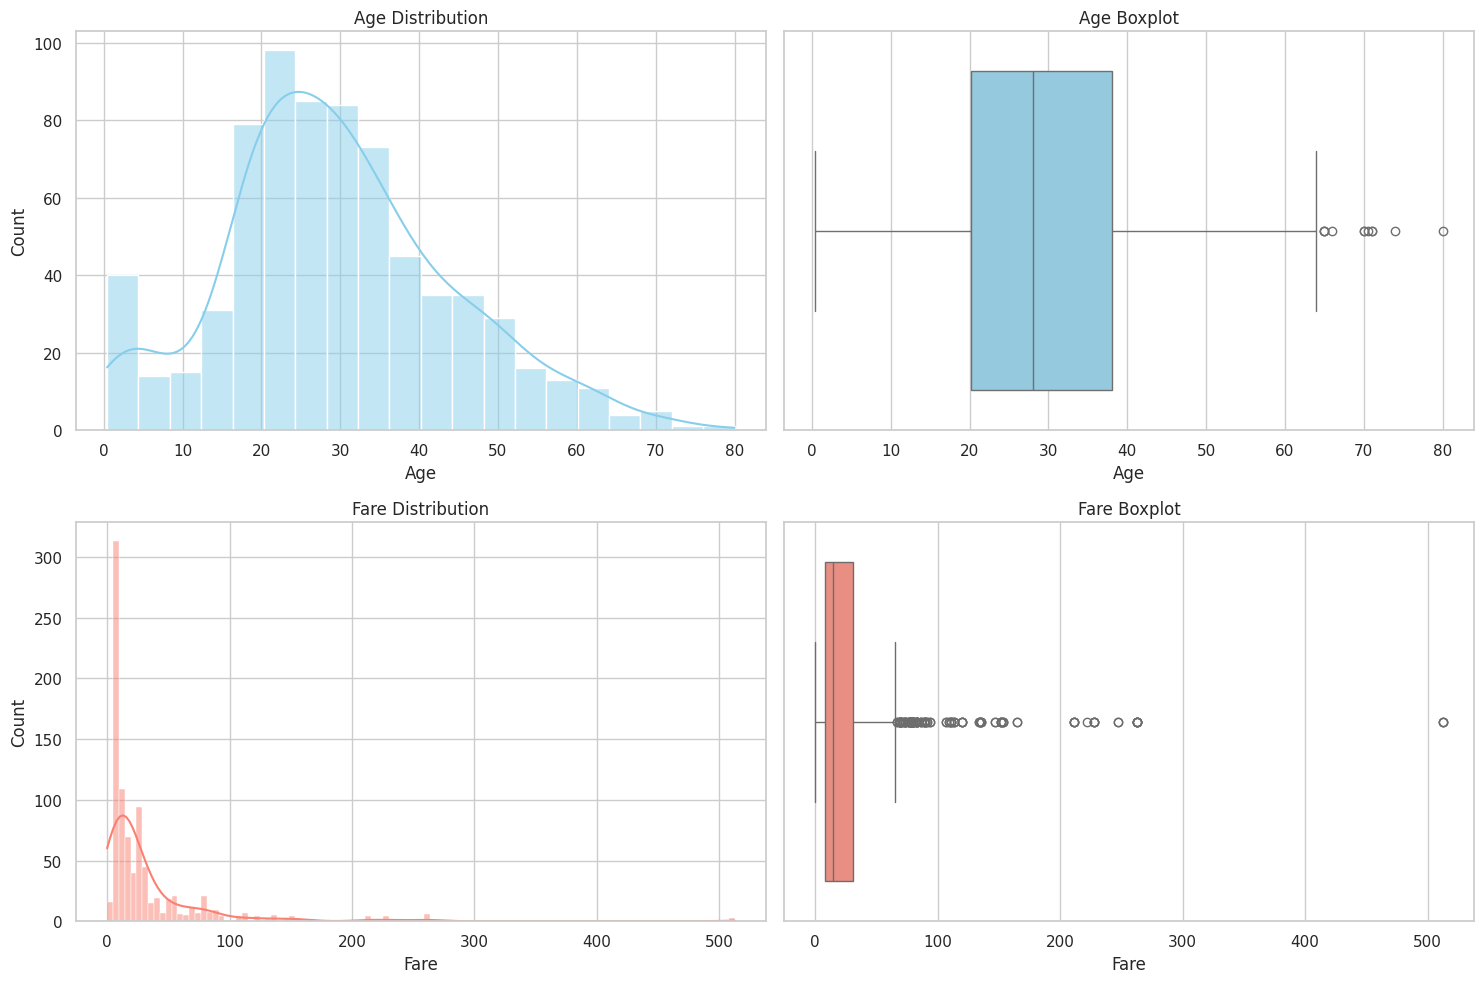

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

sns.boxplot(x=df['Age'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Age Boxplot')

sns.histplot(df['Fare'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Fare Distribution')

sns.boxplot(x=df['Fare'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Fare Boxplot')

plt.tight_layout()
plt.show()

### 4. Categorical Analysis and Relationships

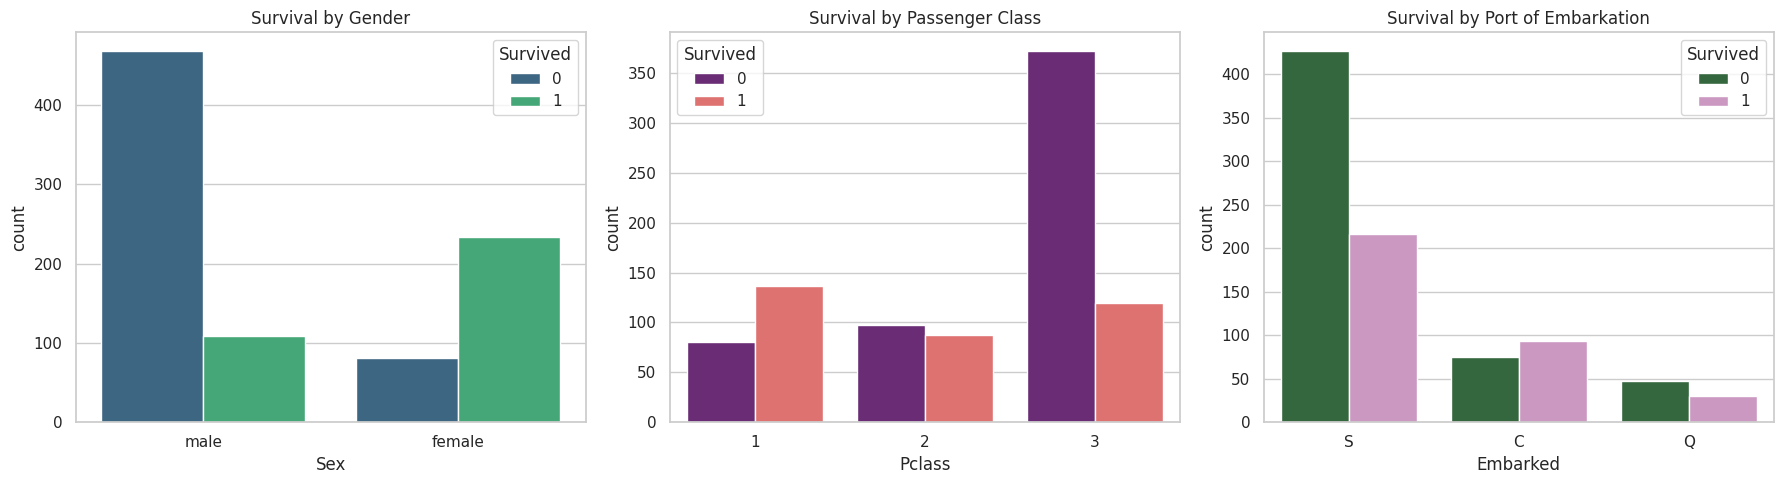

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0], palette='viridis')
axes[0].set_title('Survival by Gender')

sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[1], palette='magma')
axes[1].set_title('Survival by Passenger Class')

sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[2], palette='cubehelix')
axes[2].set_title('Survival by Port of Embarkation')

plt.tight_layout()
plt.show()

### 5. Correlation Heatmap

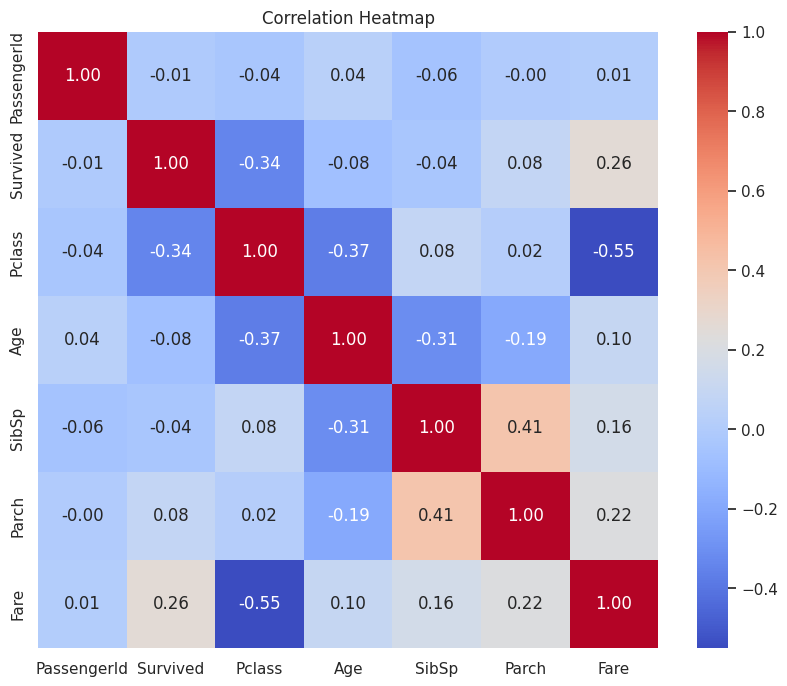

In [5]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 6. Outlier Detection (IQR Method)

In [6]:
def calculate_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

num_outliers_age = calculate_outliers_iqr(df, 'Age')
print(f"Number of outliers in Age: {num_outliers_age}")

num_outliers_fare = calculate_outliers_iqr(df, 'Fare')
print(f"Number of outliers in Fare: {num_outliers_fare}")

Number of outliers in Age: 11
Number of outliers in Fare: 116


### 7. Interactive Scatter Plot Analysis

In [7]:
fig = px.scatter(df, x='Age', y='Fare', color='Survived',
                 hover_data=['Name', 'Sex', 'Pclass'],
                 title='Interactive Scatter: Age vs Fare (colored by Survival)')
fig.show()